# SW 4 — per-CR archive and animation

CR 2306, run through the same library functions as the Make scripts so each intermediate can be inspected. This notebook reads SQL CH-area input and publishes a sample archive without satellite comparisons; SQL's upstream gap filling is not yet audited.

In [1]:
import os
import json
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/helio_n_matplotlib")
os.environ.setdefault("SUNPY_CONFIGDIR", "/tmp/helio_n_sunpy")

import numpy as np
import pandas as pd
from IPython.display import Video, display
from sunpy.coordinates.sun import carrington_rotation_number

project_root = Path.cwd().resolve()
if not (project_root / "Library").exists():
    project_root = project_root.parent
assert (project_root / "Library").exists()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Library.SW.Archive import cr_bounds, load_cr, load_cube, load_inputs, load_series, write_cr
from Library.SW.Ballistic import cube_stats, propagate_ballistic
from Library.SW.Config import load_ballistic_spec, load_empirical_spec
from Library.SW.Coords import compute_rotation_state
from Library.SW.Inputs import build_model_input_series, load_sw_input_frame
from Library.SW.Visualization import export_polar_animation, plot_polar_snapshot


/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l1dcachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l2cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.l3cachesize'. Detail: [errno 1] Operation not permitted
/Users/runner/work/crossbow/crossbow/arrow/cpp/src/arrow/util/cpu_info.cc:239: IOError: sysctlbyname failed for 'hw.optional.neon'. Detail: [errno 1] Operation not permitted


## 1. Select the rotation and load its source

The requested date range starts before CR 2306. Select the next CR as in the current experiment; the archive itself owns only its rounded CR interval. The SQL read uses the same 40-day source guard as `propagate_sw`.

In [2]:
date_range = (pd.Timestamp("2025-12-25"), pd.Timestamp("2026-01-12"))
cr = int(np.ceil(carrington_rotation_number(date_range[0])))
ballistic = load_ballistic_spec()
cr_start, cr_end = cr_bounds(cr, ballistic["output_step_minutes"])
cr, cr_start, cr_end

(2306, Timestamp('2025-12-27 09:00:00'), Timestamp('2026-01-23 17:00:00'))

In [3]:
archive_root = project_root / "Outputs/SW/Samples/Archive"
source_guard_days = 40.0
source_start = cr_start - pd.Timedelta(days=source_guard_days)
inputs = load_sw_input_frame(start_dt=source_start, end_dt=cr_end, source="sql")
inputs["source_quality"] = np.where(inputs["ch_relative_area"].notna(), "available", "missing")
display(pd.Series({"rows": len(inputs), "missing CH area": int(inputs["ch_relative_area"].isna().sum())}))
inputs

rows               979
missing CH area      0
dtype: int64

,dt,forecast_dt,forecast_sw_speed,ch_relative_area,source_quality
0,2025-11-14 12:00:00,2025-11-17 09:11:45.994613,600.547571,2.35,available
1,2025-11-14 15:00:00,2025-11-17 13:22:42.372100,590.458633,2.22,available
2,2025-11-14 16:00:00,2025-11-17 15:08:26.318410,584.132406,2.14,available
3,2025-11-14 17:00:00,2025-11-17 19:29:47.231700,557.819248,1.82,available
4,2025-11-14 18:00:00,2025-11-17 20:36:36.945871,556.968358,1.81,available
...,...,...,...,...,...
974,2026-01-20 06:00:00,2026-01-23 12:03:53.748605,532.320409,1.53,available
975,2026-01-20 07:00:00,2026-01-23 13:03:53.748605,532.320409,1.53,available
976,2026-01-20 08:00:00,2026-01-23 13:32:12.690457,535.945825,1.57,available
977,2026-01-20 09:00:00,2026-01-23 15:20:01.572820,530.493495,1.51,available


## 2. Build the hourly boundary speeds

`prepared` retains the valid source rows with empirical speeds; `prepared["df_v"]` is the hourly series passed to the propagator. The original `inputs` above still shows any missing CH-area rows.

In [4]:
empirical = load_empirical_spec()
step = int(ballistic["output_step_minutes"])
rotation = compute_rotation_state(ballistic["phi_step_minutes"])
prepared = build_model_input_series(
    sdo_input_df=inputs, empirical=empirical, output_step_minutes=step,
    simulation_pad_days=ballistic["simulation_pad_days"],
)
display(prepared["sdo_input_df"])
prepared["df_v"]

,dt,forecast_dt,forecast_sw_speed,ch_relative_area,source_quality,v_empirical
0,2025-11-14 12:00:00,2025-11-17 09:11:45.994613,600.547571,2.35,available,600.547571
1,2025-11-14 15:00:00,2025-11-17 13:22:42.372100,590.458633,2.22,available,590.458633
2,2025-11-14 16:00:00,2025-11-17 15:08:26.318410,584.132406,2.14,available,584.132406
3,2025-11-14 17:00:00,2025-11-17 19:29:47.231700,557.819248,1.82,available,557.819248
4,2025-11-14 18:00:00,2025-11-17 20:36:36.945871,556.968358,1.81,available,556.968358
...,...,...,...,...,...,...
974,2026-01-20 06:00:00,2026-01-23 12:03:53.748605,532.320409,1.53,available,532.320409
975,2026-01-20 07:00:00,2026-01-23 13:03:53.748605,532.320409,1.53,available,532.320409
976,2026-01-20 08:00:00,2026-01-23 13:32:12.690457,535.945825,1.57,available,535.945825
977,2026-01-20 09:00:00,2026-01-23 15:20:01.572820,530.493495,1.51,available,530.493495


,v
time,
2025-11-14 12:00:00,600.547571
2025-11-14 15:00:00,590.458633
2025-11-14 16:00:00,584.132406
2025-11-14 17:00:00,557.819248
2025-11-14 18:00:00,556.968358
...,...
2026-01-20 06:00:00,532.320409
2026-01-20 07:00:00,532.320409
2026-01-20 08:00:00,535.945825


## 3. Propagate and inspect the cube

The solver returns the grid, speed cube, and runtime statistics. `cube_stats` leaves speed unchanged and computes the current inferred slow-wind mask and display range.

In [5]:
grid, speed, propagation_stats = propagate_ballistic(
    df_v_run=prepared["df_v"],
    sim_start=min(prepared["sim_start"], cr_start),
    sim_end=max(prepared["sim_end"], cr_end),
    output_step_minutes=step, rotation_state=rotation,
    r0=ballistic["r0"], r_max=ballistic["r_max"], r_step=ballistic["r_step"],
    maximum_source_gap_hours=ballistic["maximum_input_gap_hours"],
)
cube_info = cube_stats(speed, empirical.slow_sw_speed(grid.time_axis))
core = (grid.time_axis >= cr_start) & (grid.time_axis < cr_end)
display(pd.Series({
    "cube shape": speed.shape, "core frames": int(core.sum()),
    "finite fraction": float(np.isfinite(speed[core]).mean()),
    "source points": propagation_stats.source_points,
    "source segments": propagation_stats.source_segments,
    "propagation seconds": propagation_stats.prop_seconds,
    "slow-wind cells": cube_info.slow_cells,
}))
cube_info.speed_range

Ballistic shells:   0%|          | 0/131 [00:00<?, ?shell/s]

cube shape             (1774, 328, 131)
core frames                         656
finite fraction                0.790217
source points                       977
source segments                     942
propagation seconds            0.597499
slow-wind cells                 5398271
dtype: object

(300.0, 799.5061645507812)

## 4. Publish one sample CR

No satellite comparison is made here: the local STEREO-A data ends in 2019 and ACE covers only part of this CR. The retained `series.parquet` therefore contains only the rounded-core CH-area and empirical-input columns. An existing archive is not overwritten; the in-memory intermediates above are still recomputed on each run.

In [6]:
input_series = pd.concat({
    "ch_area": prepared["df_ch_area"],
    "model_input": prepared["df_v"].rename(columns={"v": "v_empirical"}),
}, axis="columns")
series = pd.concat({"input": input_series}, axis="columns").sort_index()
series = series.loc[(series.index >= cr_start) & (series.index < cr_end)]
metadata = {
    "model": "continuous_ballistic", "mode": "hindcast",
    "created_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    "input_source": "sql", "source_guard_days": source_guard_days,
    "source_start_utc": source_start.isoformat(),
    "previous_cr": cr - 1, "next_cr": cr + 1,
    "input_rows": len(inputs),
    "input_missing_rows": int(inputs["ch_relative_area"].isna().sum()),
    "source_points": propagation_stats.source_points,
    "source_segments": propagation_stats.source_segments,
    "maximum_input_gap_hours": ballistic["maximum_input_gap_hours"],
    "output_step_minutes": step,
    "config": json.loads(Path(ballistic["json_path"]).read_text()),
    "upstream_sql_fill_unresolved": True,
    "comparison_data": "none",
}
archive_dir = archive_root / f"CR{cr:04d}"
if archive_dir.exists():
    print(f"Reusing {archive_dir}; this run's intermediates were not published")
else:
    archive_dir = write_cr(
        archive_root, cr, grid.time_axis[core], grid.phi_axis, grid.r_axis,
        speed[core], cube_info.slow_wind_mask[core], inputs,
        prepared["sdo_input_df"], series, metadata,
    )
archive_dir

PosixPath('/Users/aosh/Developer/helio-n/Outputs/SW/Samples/Archive/CR2306')

## 5. Reopen the archived cube and inputs

`speed` and `is_slow_wind` are separate arrays with named `(time, phi, r)` coordinates. Missing speed stays NaN. `load_inputs(..., prepared=True)` retrieves the effective boundary rows. This sample's `series` has only input columns; adjacent CR archives can later be concatenated by date range.

In [7]:
cube = load_cr(archive_root, cr)
series = load_series(archive_root, cr_start, cr_end)
summary = pd.Series({
    "frames": cube.sizes["time"],
    "longitudes": cube.sizes["phi"],
    "shells": cube.sizes["r"],
    "finite_fraction": float(np.isfinite(cube.speed.values).mean()),
    "series_rows": len(series),
})
display(summary)
display(load_inputs(archive_root, cr))
display(load_inputs(archive_root, cr, prepared=True))
series


frames             656.000000
longitudes         328.000000
shells             131.000000
finite_fraction      0.790217
series_rows        318.000000
dtype: float64

,dt,forecast_dt,forecast_sw_speed,ch_relative_area,source_quality
0,2025-11-14 12:00:00,2025-11-17 09:11:45.994613,600.547571,2.35,available
1,2025-11-14 15:00:00,2025-11-17 13:22:42.372100,590.458633,2.22,available
2,2025-11-14 16:00:00,2025-11-17 15:08:26.318410,584.132406,2.14,available
3,2025-11-14 17:00:00,2025-11-17 19:29:47.231700,557.819248,1.82,available
4,2025-11-14 18:00:00,2025-11-17 20:36:36.945871,556.968358,1.81,available
...,...,...,...,...,...
974,2026-01-20 06:00:00,2026-01-23 12:03:53.748605,532.320409,1.53,available
975,2026-01-20 07:00:00,2026-01-23 13:03:53.748605,532.320409,1.53,available
976,2026-01-20 08:00:00,2026-01-23 13:32:12.690457,535.945825,1.57,available
977,2026-01-20 09:00:00,2026-01-23 15:20:01.572820,530.493495,1.51,available


,dt,forecast_dt,forecast_sw_speed,ch_relative_area,source_quality,v_empirical
0,2025-11-14 12:00:00,2025-11-17 09:11:45.994613,600.547571,2.35,available,600.547571
1,2025-11-14 15:00:00,2025-11-17 13:22:42.372100,590.458633,2.22,available,590.458633
2,2025-11-14 16:00:00,2025-11-17 15:08:26.318410,584.132406,2.14,available,584.132406
3,2025-11-14 17:00:00,2025-11-17 19:29:47.231700,557.819248,1.82,available,557.819248
4,2025-11-14 18:00:00,2025-11-17 20:36:36.945871,556.968358,1.81,available,556.968358
...,...,...,...,...,...,...
974,2026-01-20 06:00:00,2026-01-23 12:03:53.748605,532.320409,1.53,available,532.320409
975,2026-01-20 07:00:00,2026-01-23 13:03:53.748605,532.320409,1.53,available,532.320409
976,2026-01-20 08:00:00,2026-01-23 13:32:12.690457,535.945825,1.57,available,535.945825
977,2026-01-20 09:00:00,2026-01-23 15:20:01.572820,530.493495,1.51,available,530.493495


input            
                             ch_area model_input
                    ch_relative_area v_empirical
time                                            
2025-12-27 12:00:00             2.11  581.735763
2025-12-27 13:00:00             2.20  588.885746
2025-12-27 14:00:00             2.20  588.885746
2025-12-27 15:00:00             2.16  585.722707
2025-12-27 16:00:00             2.19  588.097158
...                              ...         ...
2026-01-20 06:00:00             1.53  532.320409
2026-01-20 07:00:00             1.53  532.320409
2026-01-20 08:00:00             1.57  535.945825
2026-01-20 09:00:00             1.51  530.493495
2026-01-20 10:00:00             1.49  528.656876

[318 rows x 2 columns]

In [8]:
window_start = max(date_range[0], cr_start)
window_end = window_start + pd.Timedelta(hours=6)
assert window_end <= min(date_range[1], cr_end)
window_cube = load_cube(archive_root, window_start, window_end)
window_series = load_series(archive_root, window_start, window_end)
assert window_cube.sizes["time"] == 6
display(window_series)
window_cube.speed.isel(time=0)


input            
                             ch_area model_input
                    ch_relative_area v_empirical
time                                            
2025-12-27 12:00:00             2.11  581.735763
2025-12-27 13:00:00             2.20  588.885746
2025-12-27 14:00:00             2.20  588.885746

<xarray.DataArray 'speed' (phi: 328, r: 131)> Size: 172kB
array([[      nan,       nan,       nan, ..., 403.6331 , 404.93964,
        406.4269 ],
       [      nan,       nan,       nan, ..., 407.7214 , 409.32547,
        411.13913],
       [      nan, 527.73486, 527.73486, ..., 412.8012 , 414.78104,
        416.7536 ],
       ...,
       [636.46155, 632.3315 , 628.14636, ..., 398.49686, 399.47183,
        400.79184],
       [618.44293, 614.19086, 609.87866, ..., 401.80786, 403.3148 ,
        404.92734],
       [600.4243 , 596.0428 , 594.8126 , ..., 406.21722, 407.3971 ,
        408.20184]], dtype=float32)
Coordinates:
  * phi      (phi) float32 1kB 0.0 1.1 2.2 3.3 4.4 ... 356.4 357.5 358.6 359.7
  * r        (r) float32 524B 20.0 21.5 23.0 24.5 ... 210.5 212.0 213.5 215.0
    time     datetime64[ns] 8B 2025-12-27T09:00:00

## 6. Inspect a 2D still frame

This polar frame uses the in-memory solver result, with no satellite panel. It can be inspected before or after publishing the archive.

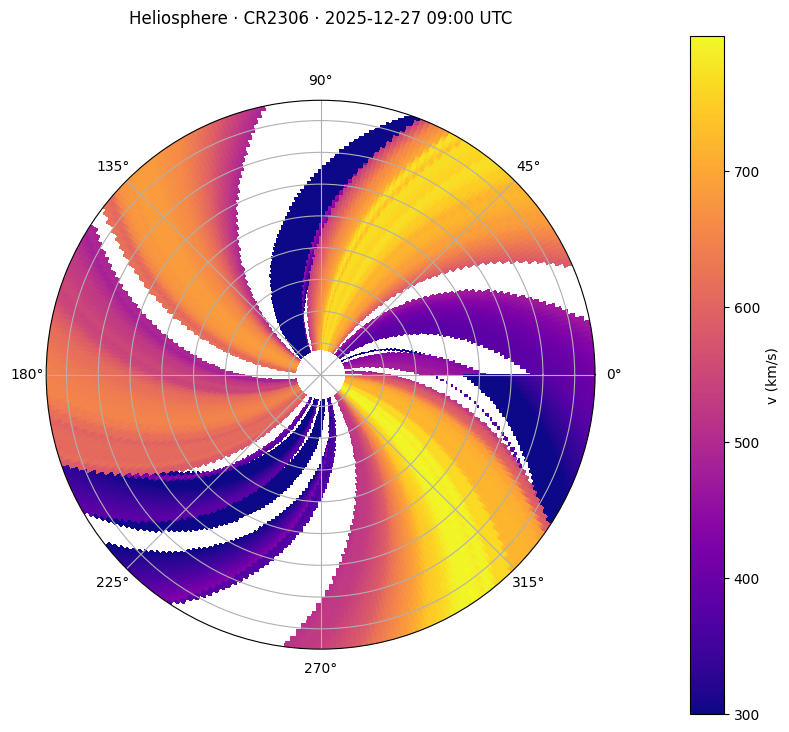

In [9]:
plot_polar_snapshot(
    str(window_start), grid.time_axis, grid.phi_axis, grid.r_axis,
    speed, cube_info.speed_range, cube_info.slow_wind_mask,
    empirical.slow_sw_speed(grid.time_axis), {},
)


## 7. Build a short movie from the archive

Call the same `export_polar_animation` function as `make_animation`, using the six archived hourly frames above. No script or satellite comparison is involved. A padded CR movie would also need the neighboring CR archives.

In [10]:
movie = project_root / f"Outputs/SW/Samples/SW Animation CR{cr} 6h.mp4"
movie_times = pd.DatetimeIndex(window_cube.time.values)
movie_speed = window_cube.speed.values
movie_finite = movie_speed[np.isfinite(movie_speed)]
assert len(movie_finite) > 0
export_result = export_polar_animation(
    anim_outfile=movie, time_axis=movie_times,
    phi_axis=window_cube.phi.values, r_axis=window_cube.r.values,
    grid_raw=movie_speed,
    post_vlims_raw=(float(movie_finite.min()), float(movie_finite.max())),
    slow_sw_pred_mask=window_cube.is_slow_wind.values,
    slow_sw_speed=empirical.slow_sw_speed(movie_times),
    comparison_frames={}, anim_fps=6, anim_dpi=70,
)
display(export_result)
display(Video(filename=str(movie), embed=True))


Export MP4:   0%|          | 0/6 [00:00<?, ?frame/s]

{'frames': 6.0, 'fps': 6.0}